需要将该文件放到 OmDet 项目根目录下

In [1]:
import os
import sys
sys.path.append('/data25/wuqin/projects/pytorch-grad-cam')
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
os.environ['HOME'] = '/data25/wuqin'

## OmDet 推理示例

In [2]:
from omdet.inference.det_engine import DetEngine
engine = DetEngine(batch_size=1, device='cuda')

/data25/wuqin/miniforge3/envs/omdet/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
img_paths = ['/data25/wuqin/projects/visual_bge/vl_query_samples/imgs/test1.jpg']       # path of images
labels = ["the left plant"]          # labels to be predicted
prompt = 'Detect {}.'.format(','.join(labels))        # prompt of detection task, use "Detect {}." as default
model_id = 'OmDet-Turbo_tiny_SWIN_T'

res = engine.inf_predict(model_id,    # prefix name of the pretrained checkpoints
                        task=prompt,
                        data=img_paths,
                        labels=labels,
                        src_type='local',                     # type of the image_paths, "local"/"url"
                        conf_threshold=0.30,
                        nms_threshold=0.5
                        )

Config 'configs/OmDet-Turbo_tiny_SWIN_T.yaml' has no VERSION. Assuming it to be compatible with latest v2.
/data25/wuqin/miniforge3/envs/omdet/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1695392022560/work/aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/data25/wuqin/miniforge3/envs/omdet/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1695392022560/work/aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


cfg.MODEL.LANGUAGE_BACKBONE.MODEL_TYPE clip
[08/05 08:12:19 omdet.inference.det_engine]: Model:
OmDetV2Turbo(
  (backbone): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0): BasicLayer(
        (blocks): ModuleList(
          (0): SwinTransformerBlock(
            (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=96, out_features=288, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=96, out_features=96, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path): Identity()
            (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=

In [4]:
print(res)

[[{'xmin': 2172, 'ymin': 1614, 'xmax': 3635, 'ymax': 2557, 'conf': 0.4752822816371918, 'label': 'the left plant'}, {'xmin': 322, 'ymin': 1520, 'xmax': 1367, 'ymax': 2495, 'conf': 0.46018317341804504, 'label': 'the left plant'}]]


检测到 2 个目标: ['the left plant: 0.48', 'the left plant: 0.46']
缩放后的框坐标: [(339, 336, 567, 532), (50, 316, 213, 519)]


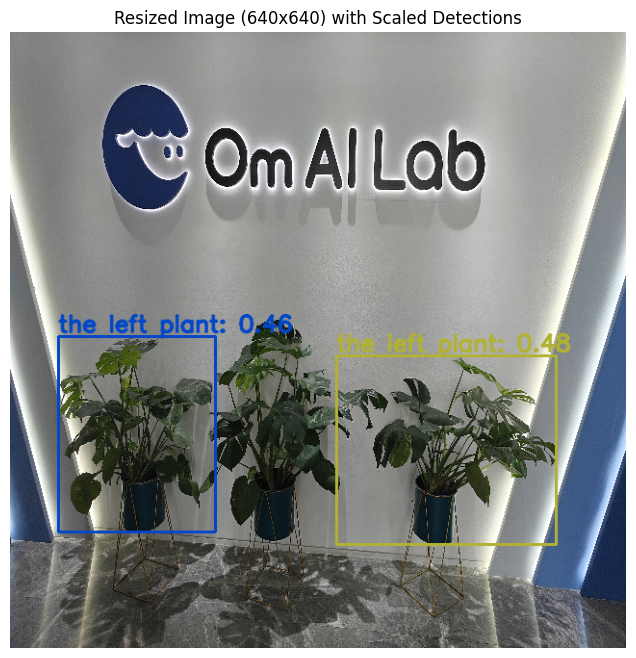

In [17]:
# 解析检测结果并缩放坐标
import numpy as np
import matplotlib.pyplot as plt
import cv2

def draw_detections(boxes, colors, names, img):
    """在图像上绘制检测框"""
    img_copy = img.copy()
    for box, color, name in zip(boxes, colors, names):
        xmin, ymin, xmax, ymax = box
        cv2.rectangle(img_copy, (xmin, ymin), (xmax, ymax), color, 2)
        cv2.putText(img_copy, name, (xmin, ymin - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2,
                    lineType=cv2.LINE_AA)
    return img_copy
def parse_omdet_detections(res, scale_x=1, scale_y=1):
    """解析 OmDet 检测结果并缩放坐标"""
    boxes, colors, names = [], [], []
    if res and len(res) > 0:
        detections = res[0]  # 取第一张图片的结果
        for det in detections:
            # 缩放坐标到调整后的图像尺寸
            xmin = int(det['xmin'] * scale_x)
            ymin = int(det['ymin'] * scale_y)
            xmax = int(det['xmax'] * scale_x)
            ymax = int(det['ymax'] * scale_y)
            label = det['label']
            conf = det['conf']

            boxes.append((xmin, ymin, xmax, ymax))
            colors.append(np.random.uniform(0, 255, size=3))  # 随机颜色
            names.append(f"{label}: {conf:.2f}")

    return boxes, colors, names

img_raw = cv2.cvtColor(cv2.imread(img_paths[0]), cv2.COLOR_BGR2RGB)
boxes, colors, names = parse_omdet_detections(res, 640 / img_raw.shape[1], 640 / img_raw.shape[0])
print(f"检测到 {len(boxes)} 个目标: {names}")
if len(boxes) > 0:
    print(f"缩放后的框坐标: {boxes}")

# 显示带检测框的原图
img_raw = cv2.resize(img_raw, (640, 640))
detections_img = draw_detections(boxes, colors, names, img_raw.copy())
plt.figure(figsize=(8, 8))
plt.imshow(detections_img)
plt.title('Resized Image (640x640) with Scaled Detections')
plt.axis('off')
plt.show()

## OmDet CAM支持

In [5]:
# 重新实现OmDetV2Turbo类，使其支持直接接受预处理好的image_tensor
import torch
from detectron2.structures import ImageList

class OmDetV2TurboCAM(torch.nn.Module):
    """
    为EigenCAM优化的OmDetV2Turbo包装类
    将forward方法分解为prepare_forward和forward，便于CAM可视化
    """

    def __init__(self, engine):
        super().__init__()
        self.engine = engine
        self.model, self.cfg = engine._load_model(model_id)

        self.batch_inputs = None
        self.label_feats = None
        self.prompt_feats = None
        self.prompt_mask = None
        self.conf_thresh = None
        self.nms_thresh = None

    def prepare_forward(self, image_path, task, labels, conf_thresh, nms_thresh):
        """
        准备前向传播所需的所有数据

        Args:
            image_path: 准备处理的图片路径
        """
        batch_image = self.engine._load_data('local', self.cfg, [image_path])
        for img in batch_image:
            img['label_set'] = labels
            img['tasks'] = task
        # 获取语言嵌入
        label_feats, prompt_feats, prompt_mask = self.model.get_language_embedding(batch_image)

        self.batch_inputs = batch_image
        self.label_feats = label_feats
        self.prompt_feats = prompt_feats
        self.prompt_mask = prompt_mask
        self.conf_thresh = conf_thresh
        self.nms_thresh = nms_thresh

        return self.model.preprocess_image(batch_image)[0].tensor

    def forward(self, image_tensor):
        """
        简化的forward方法，只接受预处理好的image_tensor

        Args:
            image_tensor: 预处理好的图像张量 [B, C, H, W]
        """
        if self.batch_inputs is None or self.label_feats is None or self.prompt_feats is None or self.prompt_mask is None:
            raise ValueError("请先调用prepare_forward方法")

        # 创建ImageList结构
        images = ImageList(image_tensor, [(image_tensor.shape[2], image_tensor.shape[3])])

        # Backbone特征提取
        body_feats = self.model.backbone(images.tensor)

        if type(body_feats) is dict:
            body_feats = [body_feats[i] for i in body_feats.keys()]

        # Encoder
        encoder_feats = self.model.neck(body_feats)

        if not self.training:
            # Decoder
            decoder_feats = self.model.decoder(
                encoder_feats,
                self.label_feats,
                self.prompt_feats,
                self.prompt_mask
            )

            # Head
            box_pred, box_cls, _ = self.model.loss_head(decoder_feats)

            results = self.model.gen_output(box_cls, box_pred, self.batch_inputs, images,
                            self.conf_thresh, self.nms_thresh, True,
                            max_num_det=self.model.num_proposals)

        #
        resp = []
        for z in results:
            temp = []
            instances = z['instances'].to('cpu')
            instances = instances[instances.scores > self.conf_thresh]

            for idx, pred in enumerate(zip(instances.pred_boxes, instances.scores, instances.pred_classes)):
                (x, y, xx, yy), conf, cls = pred
                conf = float(conf)
                cls = self.batch_inputs[0]['label_set'][int(cls)]

                temp.append({'xmin': int(x),
                                'ymin': int(y),
                                'xmax': int(xx),
                                'ymax': int(yy),
                                'conf': conf,
                                'label': cls})
            resp.append(temp)

        return resp

omdet_cam = OmDetV2TurboCAM(engine)

In [6]:
input_tensor = omdet_cam.prepare_forward(img_paths[0], prompt, labels, 0.3, 0.5)
print(input_tensor.shape)

[08/05 08:12:31 omdet.omdet_v2_turbo.detector]: processing labels embeddings for ['the left plant']
[08/05 08:12:31 omdet.omdet_v2_turbo.detector]: cached label emb num: 1, not cached num: 0
[08/05 08:12:31 omdet.omdet_v2_turbo.detector]: processing prompt embeddings for ['Detect the left plant.']
[08/05 08:12:31 omdet.omdet_v2_turbo.detector]: cached prompt emb num: 1, not cached num: 0
torch.Size([1, 3, 640, 640])
[08/05 08:12:31 omdet.omdet_v2_turbo.detector]: cached label emb num: 1, not cached num: 0
[08/05 08:12:31 omdet.omdet_v2_turbo.detector]: processing prompt embeddings for ['Detect the left plant.']
[08/05 08:12:31 omdet.omdet_v2_turbo.detector]: cached prompt emb num: 1, not cached num: 0
torch.Size([1, 3, 640, 640])


In [7]:
def omdet_encoder_reshape_transforme(x):
    # target_size = x[0].shape[-2:]
    target_size = x['swin1'].shape[-2:]
    activations = []
    # for feat in x:
    for key, feat in x.items():
        activations.append(
            torch.nn.functional.interpolate(
                torch.abs(feat),
                target_size,
                mode='bilinear'))
    activations = torch.cat(activations, axis=1)
    return activations

In [8]:
img = omdet_cam.batch_inputs[0]['image'].permute(1, 2, 0)/255
img = img.numpy()

CAM形状: (640, 640)


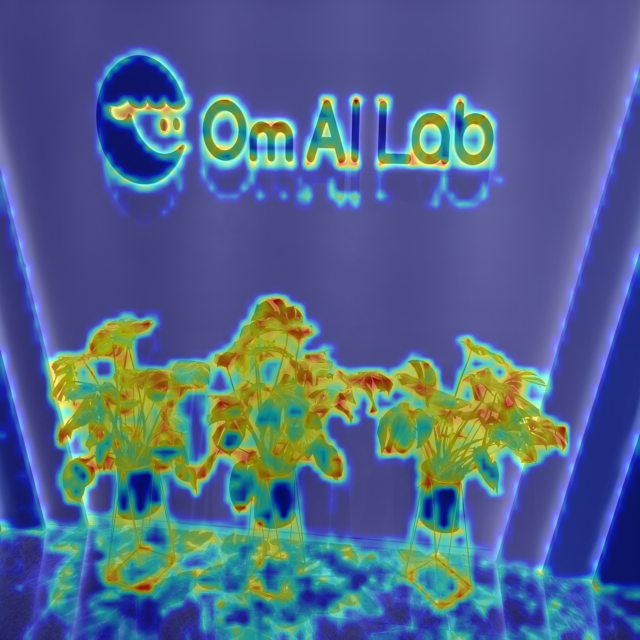

In [20]:
# 创建EigenCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam import EigenCAM
target_layers = [omdet_cam.model.backbone]
targets = [ClassifierOutputTarget(0)]

# cam = EigenCAM(omdet_cam, target_layers, reshape_transform=omdet_encoder_reshape_transforme)
cam = EigenCAM(omdet_cam, target_layers, reshape_transform=lambda x: x['swin1'])

with torch.no_grad():
    grayscale_cam = cam(input_tensor, targets=targets)[0, :, :]
print(f"CAM形状: {grayscale_cam.shape}")
from PIL import Image
from pytorch_grad_cam.utils.image import show_cam_on_image
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
Image.fromarray(cam_image)

In [18]:
import numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image, scale_cam_image

# 辅助函数：在边界框内重新归一化CAM
def renormalize_cam_in_bounding_boxes(boxes, colors, names, image_float_np, grayscale_cam):
    """在每个边界框内将CAM归一化到[0,1]范围，边界框外为0"""
    renormalized_cam = np.zeros(grayscale_cam.shape, dtype=np.float32)
    for x1, y1, x2, y2 in boxes:
        renormalized_cam[y1:y2, x1:x2] = scale_cam_image(grayscale_cam[y1:y2, x1:x2].copy())
    renormalized_cam = scale_cam_image(renormalized_cam)
    eigencam_image_renormalized = show_cam_on_image(image_float_np, renormalized_cam, use_rgb=True)
    image_with_bounding_boxes = draw_detections(boxes, colors, names, eigencam_image_renormalized)
    return image_with_bounding_boxes

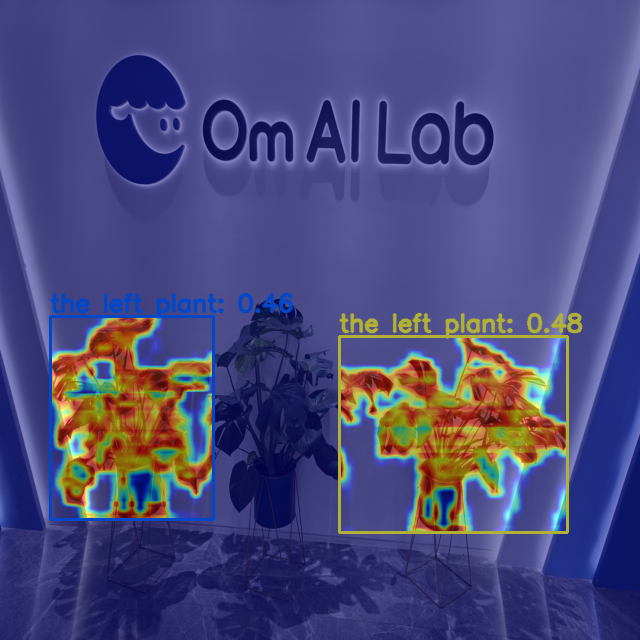

In [21]:
# 在边界框内重新归一化CAM
if len(boxes) > 0:
    renormalized_cam_image = renormalize_cam_in_bounding_boxes(boxes, colors, names, img, grayscale_cam)
else:
    renormalized_cam_image = cam_image
Image.fromarray(renormalized_cam_image)